In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pygame
import sys
import json
import yaml
import re
import nltk
from nltk.tokenize import sent_tokenize
from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.stats import pearsonr
import re
from collections import defaultdict
import plotly.graph_objects as go
import PIL.Image




nltk.download('punkt')

IMAGE_PATH = "image.png"

c:\Users\bapti\miniforge3\envs\spatial\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bapti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
def choose_segments_points(nb_segments):
    pygame.init()
    img = pygame.image.load(IMAGE_PATH)
    w, h = img.get_size()

    screen = pygame.display.set_mode((w, h))
    pygame.display.set_caption("Click to get coordinates")

    clicked_points = []

    running = True
    while running:
        screen.fill((255, 255, 255))
        screen.blit(img, (0, 0))

        # Draw clicked points
        for pt in clicked_points:
            pygame.draw.circle(screen, (255, 0, 0), pt, 5)  # red dot
        # Draw lines
        if len(clicked_points) > 1:
            pygame.draw.lines(screen, (0, 0, 255), False, clicked_points, 2)

        pygame.display.flip()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN:
                x, y = event.pos
                clicked_points.append((x, y))
                print(f"Clicked at: ({x}, {y})")
        running = len(clicked_points) <= nb_segments

    pygame.quit()
    return clicked_points


In [3]:
clicked_points = [
    (89, 514),
    (369, 452),
    (497, 432),
    (609, 421),
    (596, 374),
    (505, 306),
    (559, 206),
    (532, 69),
]

if clicked_points is None:
    clicked_points = choose_segments_points(7)

with open('corresp_segments.json', 'r') as f:
    corresp = json.load(f)

In [4]:
ratings_directory = "/Users/bapti/Desktop/Nouveau dossier/segments_P0{x}.yaml"
def get_segment_ratings_and_feedback(participant):
    ratings = {}
    feedback = {}
    with open(ratings_directory.format(x=participant), encoding='UTF8') as file:
        segments = yaml.safe_load(file)['segments']
    for segment in segments:
        ratings[str(segment['segment_id'])] = segment['walkability_rating']
        feedback[str(segment['segment_id'])] = segment['feedback']
    return ratings, feedback

def get_all_ratings_and_feedback(nb_participants):
    ratings = {}
    feedback = {}
    for i in range(nb_participants):
        ratings[i+1], feedback[i+1] = get_segment_ratings_and_feedback(i+1)
    return ratings, feedback

In [5]:
ratings, feedback = get_all_ratings_and_feedback(9)

In [ ]:
# Load image
img = PIL.Image.open(IMAGE_PATH)
w, h = img.size

fig = go.Figure()

# Add image
fig.add_layout_image(
    source=img,
    x=0, y=0,        
    sizex=w, sizey=h,
    xref="x", yref="y",
    sizing="stretch",
    layer="below"
)

# Use image coordinate system
fig.update_xaxes(
    range=[0, w],    # left to right
    constrain="domain",
    visible=False
)

fig.update_yaxes(
    range=[h, 0],
    scaleanchor="x",
    visible=False
)

num_samples = 50

for i in range(len(clicked_points) - 1):
    segments = corresp[str(i+1)]
    hovertext = f"Sous-segment {i+1}"
    for j, segment in enumerate(segments):
        rating = ratings[j+1][str(segment)]
        hovertext += f'<br>P{j+1}: Ségment {segment}, {rating}'


    x0, y0 = clicked_points[i]
    x1, y1 = clicked_points[i+1]

    # Génère 50 points entre x0,x1 et y0,y1
    xs = np.linspace(x0, x1, num_samples)
    ys = np.linspace(y0, y1, num_samples)

    fig.add_trace(go.Scatter(
        x=xs,
        y=ys,
        mode="lines",
        line=dict(width=3),
        hoverinfo="text",
        hovertext=hovertext,
    ))

fig.show()


In [7]:
nb_segments = 7
ratings_matrix = np.zeros((7, 9), dtype=float)
feedback_matrix = np.full((7, 9), '', dtype=object)
for segment_decoupe, cor in corresp.items():
    for participant, segment in enumerate(cor):
        ratings_matrix[int(segment_decoupe)-1][participant] = ratings[participant+1][str(segment)]
        feedback_matrix[int(segment_decoupe)-1][participant] = feedback[participant+1][str(segment)]
ratings_matrix

array([[4. , 1.8, 2.5, 2. , 1.5, 1.2, 1. , 3. , 1. ],
       [3.2, 4. , 4. , 3. , 4. , 3.8, 4. , 4.5, 2.5],
       [3.2, 3.4, 3. , 1.5, 3. , 2. , 2. , 3. , 2.5],
       [3.8, 3.9, 4. , 3. , 3. , 2. , 4. , 4. , 4.5],
       [3.8, 3.9, 3. , 3. , 4. , 4.2, 2. , 4. , 4.5],
       [3.7, 3.6, 3.5, 2.5, 4. , 1.8, 2. , 4. , 4. ],
       [2.5, 3.9, 2.5, 2. , 4.8, 4.5, 4. , 4. , 4. ]])

In [8]:
new_segments = "/Users/bapti/Desktop/sous-segments/segments_P0{x}.yaml"
nb_segments = 7
ratings_matrix = np.zeros((7, 9), dtype=float)
feedback_matrix = np.full((7, 9), '', dtype=object)
for participant in range(9):
    with open(new_segments.format(x=participant+1), encoding='UTF8') as file:
        segments = yaml.safe_load(file)['segments']
        for i, segment in enumerate(segments):
            assert i+1 == segment["segment_id"]
            ratings_matrix[i][participant] = segment['walkability_rating']
            feedback_matrix[i][participant] = segment['feedback']

In [9]:
min = ratings_matrix.min(axis=1)
max = ratings_matrix.max(axis=1)
mean = ratings_matrix.mean(axis=1)
std = ratings_matrix.std(axis=1)

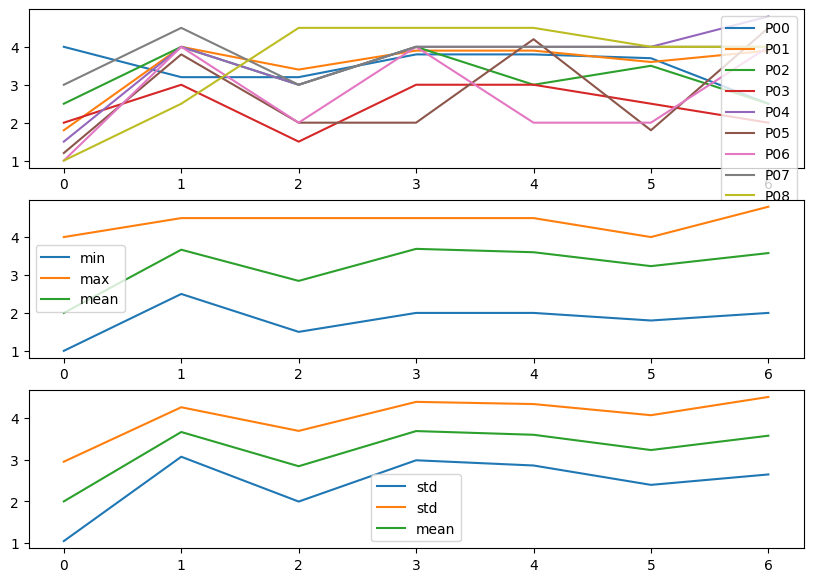

In [10]:
plt.figure(figsize=(10, 7))
plt.subplot(3, 1, 1)
for i in range(ratings_matrix.shape[1]):
    plt.plot(ratings_matrix[:, i], label=f'P0{i}')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(min, label='min')
plt.plot(max, label='max')
plt.plot(mean, label='mean')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(mean-std, label='std')
plt.plot(mean+std, label='std')
plt.plot(mean, label='mean')
plt.legend()

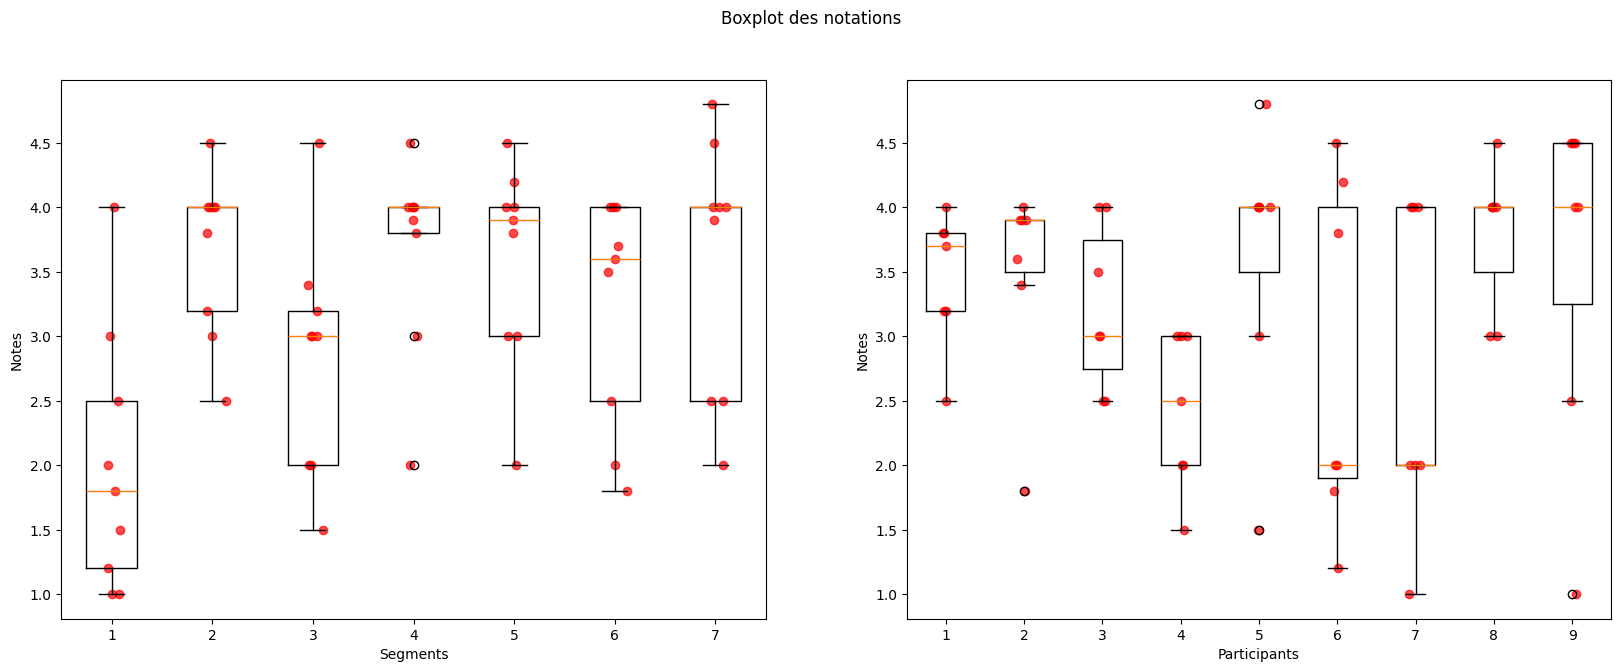

In [11]:
sctr = True
plt.figure(figsize=(20, 7))
plt.suptitle("Boxplot des notations")
R = ratings_matrix
for i, pl in enumerate(('Segments', 'Participants')):
    plt.subplot(1, 2, i+1)
    R = R.T
    num_groupes = R.shape[1]
    plt.boxplot(R, positions=range(1, num_groupes+1))

    if sctr:
        for i in range(num_groupes):
            x = np.random.normal(i+1, 0.05, size=R.shape[0])  # jitter léger
            plt.scatter(x, R[:, i], alpha=0.7, color='red')

    plt.xlabel(pl)
    plt.ylabel("Notes")
plt.show()

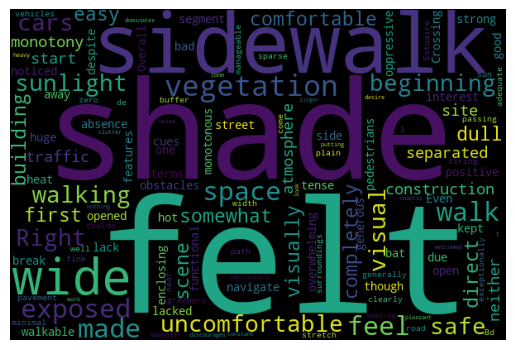

In [12]:
def plot_wordcloud(feedback_matrix, segment_idx):
    segment_feedback = feedback_matrix[segment_idx]
    text = " ".join([fb for fb in segment_feedback if isinstance(fb, str)])
    wc = WordCloud(width=600, height=400).generate(text)
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

plot_wordcloud(feedback_matrix, 0)

In [19]:
def split_into_points(sentence):
    """
    Split one sentence into candidate points using commas, semicolons, 'and', 'but'.
    """
    points = re.split(r',|;| and | but ', sentence)
    points = [p.strip() for p in points if len(p.strip()) > 2]
    return points

def collect_points(feedback_list):
    """
    Collect all points from a list of feedback strings.
    """
    points = []
    for fb in feedback_list:
        if isinstance(fb, str):
            for sentence in sent_tokenize(fb):
                points.extend(split_into_points(sentence))
    return points

model = SentenceTransformer("all-MiniLM-L6-v2")

def cluster_points(points, threshold=0.55):
    """
    Cluster similar points semantically.
    Returns a dict {cluster_id: [points]}
    """
    if len(points) == 0:
        return {}
    
    embeddings = model.encode(points, show_progress_bar=False)
    
    clustering = AgglomerativeClustering(
        n_clusters=None,
        linkage='average',
        metric='cosine',
        distance_threshold=1 - threshold
    )
    labels = clustering.fit_predict(embeddings)
    
    clusters = {}
    for label, point in zip(labels, points):
        clusters.setdefault(label, []).append(point)
    return clusters

def extract_segment_themes_topk(feedback_segment, threshold=0.55, top_k=5):
    """
    Extract clusters/themes for a single segment, keeping only top_k most common clusters.
    """
    points = collect_points(feedback_segment)
    clusters = cluster_points(points, threshold)
    
    # Sort clusters by size (number of points in cluster)
    sorted_clusters = sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)
    
    # Keep only top_k clusters
    top_clusters = dict(sorted_clusters[:top_k])
    return top_clusters

def extract_all_segments_topk(feedback_matrix, threshold=0.55, top_k=5):
    """
    Extract clusters/themes for all segments, keeping only top_k per segment.
    """
    nb_segments = feedback_matrix.shape[0]
    all_clusters = []
    for seg in range(nb_segments):
        clusters = extract_segment_themes_topk(feedback_matrix[seg, :], threshold, top_k)
        all_clusters.append(clusters)
    return all_clusters

top_k = 5  # keep top 3 themes per segment
all_themes_topk = extract_all_segments_topk(feedback_matrix, threshold=0.55, top_k=top_k)

for seg_idx, clusters in enumerate(all_themes_topk):
    print(f"\n=== Segment {seg_idx} ===")
    for rank, (theme_id, points) in enumerate(clusters.items(), start=1):
        print(f"\nTop {rank}:")
        for p in points:
            print("  -", p)



=== Segment 0 ===

Top 1:
  - there is no vegetation or shade
  - There was no vegetation or shade
  - completely exposed—no shade
  - no vegetation—and it felt oppressive in the heat.
  - there was zero vegetation or shade—walking felt exposed under 
the sun
  - There was no shade or 
vegetation
  - There was minimal shade

Top 2:
  - the sidewalk was wide
  - the sidewalk is very wide—which is positive in terms of space—
but completely exposed: it is very hot
  - the sidewalk was wide
  - the pavement was very wide
  - the sidewalk was exceptionally wide
  - The first stretch was generally fine—sidewalk width was adequate

Top 3:
  - At the beginning of the walk
  - At the beginning of the walk
  - At the very start
  - From the very beginning

Top 4:
  - Even though it was visually dull
  - the visual monotony made it dull.
  - so visually it felt plain

Top 5:
  - walking under
direct sunlight is uncomfortable.
  - was somewhat uncomfortable due to strong sunlight.
  - so walking 

# Trying else

In [ ]:
def split_into_points(sentence):
    return [p.strip() for p in re.split(r',|;| and | but ', sentence) if len(p.strip()) > 2]

def collect_points_with_segments(feedback_matrix):
    points, segments = [], []

    for seg_idx in range(feedback_matrix.shape[0]):
        for fb in feedback_matrix[seg_idx]:
            if isinstance(fb, str):
                for sentence in sent_tokenize(fb):
                    for p in split_into_points(sentence):
                        points.append(p)
                        segments.append(seg_idx)

    return points, segments

def dbscan_top10_clusters_with_outliers(feedback_matrix, eps=0.35, min_samples=3):
    model = SentenceTransformer("all-MiniLM-L6-v2")

    points, segments = collect_points_with_segments(feedback_matrix)
    if len(points) == 0:
        return {}, {}, {}

    embeddings = model.encode(points, show_progress_bar=False)

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="cosine"
    )
    labels = dbscan.fit_predict(embeddings)

    clusters = defaultdict(list)
    cluster_segment_counts = defaultdict(lambda: defaultdict(int))

    for p, s, lbl in zip(points, segments, labels):
        if lbl == -1:
            continue
        clusters[lbl].append(p)
        cluster_segment_counts[lbl][s] += 1

    top_clusters = sorted(
        clusters.keys(),
        key=lambda c: len(clusters[c]),
        reverse=True
    )[:10]

    clusters = {c: clusters[c] for c in top_clusters}
    cluster_segment_counts = {
        c: cluster_segment_counts[c] for c in top_clusters
    }

    return clusters, cluster_segment_counts, labels

clusters, cluster_segment_counts, labels = dbscan_top10_clusters_with_outliers(
    feedback_matrix, eps=0.35, min_samples=3
)

for cluster_id, seg_counts in cluster_segment_counts.items():
    print(f"\nCluster {cluster_id}")
    print("Segment distribution:", dict(seg_counts))
    for p in clusters[cluster_id][:4]:
        print("  -", p)



Cluster 0
Segment distribution: {0: 16, 1: 10, 2: 6, 3: 5, 4: 5, 5: 1, 6: 5}
  - the sidewalk was wide
  - there is no vegetation or shade
  - walking under
direct sunlight is uncomfortable.
  - was somewhat uncomfortable due to strong sunlight.

Cluster 3
Segment distribution: {0: 2, 1: 4, 2: 2, 5: 2, 6: 7}
  - walkable.
  - easy to walk on
  - the uneven surface reduced perceived walkability.
  - vegetation immediately make the walk more pleasant
and bearable

Cluster 7
Segment distribution: {1: 7, 2: 2, 3: 1, 6: 2}
  - As soon as trees appear
  - The appearance of trees changed everything: the shade
  - the presence of trees
  - I immediately felt a pleasant change: the shade from trees

Cluster 1
Segment distribution: {0: 3, 2: 2, 5: 1}
  - exposed
  - so I felt safe 
from passing cars.
  - I felt very safe—cars couldn’t come near me.
  - It felt exposed

Cluster 15
Segment distribution: {2: 1, 3: 1, 4: 1, 5: 1, 6: 1}
  - small shops.
  - small shops.
  - small shops.
  - shops

C

In [ ]:
median_ratings = np.nanmedian(ratings_matrix, axis=1)

cluster_ids = sorted(cluster_segment_counts.keys())
n_segments = ratings_matrix.shape[0]

cluster_presence = np.zeros((n_segments, len(cluster_ids)))

for j, cluster_id in enumerate(cluster_ids):
    for seg, count in cluster_segment_counts[cluster_id].items():
        cluster_presence[seg, j] = count

cluster_correlations = []

for j, cluster_id in enumerate(cluster_ids):
    presence = cluster_presence[:, j]

    if np.std(presence) == 0:
        continue

    corr, pval = pearsonr(presence, median_ratings)
    cluster_correlations.append((cluster_id, corr, pval))

cluster_correlations.sort(key=lambda x: abs(x[1]), reverse=True)

top_3_clusters = cluster_correlations[:3]

print("Top 3 clusters most correlated with segment median ratings:\n")

for rank, (cluster_id, corr, pval) in enumerate(top_3_clusters, start=1):
    print(f"Top {rank} | Cluster {cluster_id}")
    print(f"  Correlation with median rating: {corr:.3f}")
    print(f"  p-value: {pval:.3e}")
    print("  Example points:")
    for p in clusters[cluster_id][:4]:
        print("   -", p)
    print()


Top 3 clusters most correlated with segment median ratings:

Top 1 | Cluster 1
  Correlation with median rating: -0.973
  p-value: 2.341e-04
  Example points:
   - exposed
   - so I felt safe 
from passing cars.
   - I felt very safe—cars couldn’t come near me.
   - It felt exposed

Top 2 | Cluster 0
  Correlation with median rating: -0.705
  p-value: 7.683e-02
  Example points:
   - the sidewalk was wide
   - there is no vegetation or shade
   - walking under
direct sunlight is uncomfortable.
   - was somewhat uncomfortable due to strong sunlight.

Top 3 | Cluster 32
  Correlation with median rating: 0.612
  p-value: 1.439e-01
  Example points:
   - pedestrian-focused.
   - pedestrian activity
   - pedestrians is pleasant
   - pedestrians is pleasant

